In [2]:
pip install lpips

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 103.4 MB/s eta 0:00:00MB/s eta 0:00:01:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 285.9 MB/s eta 0:00:00 MB/s eta 0:00:01

[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
!ls

cbir  model	 preprocessing	scripts  training
data  notebooks  README.md	test	 utils


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pandas as pd

# Load the data
index_ds = pd.read_csv("/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/dataset_index.csv")
clinical_ds = pd.read_csv("/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/combined_metadata.csv")

# Merge on the 'GUID' column
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner")

# Inspect the result
metadata.tail()

,GUID,dataset,batch_file,index_in_batch,index_global,project,subject,timepoint,scan_type,field_strength,manufacturer,model_name,disease,age
23647,fa05462b-4363-4ae8-9ed0-3c85b1fdf6a4,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,966,23647,adni,128_S_0770,m36,T1,NaN,NaN,NaN,1.0,74.4
23648,fab4a42d-a719-4440-9bab-02cd737e1000,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,967,23648,adni,141_S_0717,v06,T1,1.5,SIEMENS,Symphony,1.0,81.4
23649,fb2bf1a8-c6ab-4809-9a3c-7daa800b9859,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,968,23649,adni,009_S_4324,v41,T1,3.0,SIEMENS,Verio,1.0,67.2
23650,fde83ef6-cb7f-457d-9e21-9c35fada74a9,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,969,23650,adni,129_S_1246,m06,T1,1.5,GE MEDICAL SYSTEMS,GENESIS_SIGNA,1.0,73.2
23651,fee2f1a0-af46-4368-9e75-20572f4d79c4,ADNI,/mimer/NOBACKUP/groups/biomedicalimaging-kth/f...,970,23651,adni,033_S_6352,init,T1,NaN,NaN,NaN,0.0,NaN


In [4]:
print(f"Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)

# Check result
print(f"Remaining rows: {len(metadata)}")


Original rows: 23652
Remaining rows: 23652


In [5]:
import torch
import numpy as np
from torch.utils.data import Dataset
import gc
import random
from collections import defaultdict


class LookupNPZDataset(Dataset):
    def __init__(self, metadata, batch_file, use_segmentation=True):
        self.metadata = metadata[metadata["batch_file"] == batch_file].reset_index(drop=True)
        self.use_segmentation = use_segmentation
        self.batch_file = batch_file

        # Load data for this batch
        npz_data = np.load(self.batch_file)

        self.images = np.array(npz_data["images"])
        self.ids = np.array(npz_data["ids"])

        if self.use_segmentation and "segmentations" in npz_data:
            self.segmentations = np.array(npz_data["segmentations"])
        else:
            self.segmentations = None

        npz_data.close()

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        index_in_batch = row["index_in_batch"]
        sample_id = row["GUID"]
        image = self.images[index_in_batch]

        sample = {
            "id": sample_id,
            "image": torch.from_numpy(image)
        }

        if self.use_segmentation and self.segmentations is not None:
            seg = self.segmentations[index_in_batch]
            sample["seg"] = torch.from_numpy(seg)

        return sample

def get_balanced_batch(dataset, group_size=4, groups_per_batch=3):
    """
    Build a batch with `groups_per_batch` patients, each with `group_size` recordings.
    Returns a list of samples.
    """
    subject_to_indices = defaultdict(list)

    for idx in range(len(dataset)):
        subject = dataset.metadata.iloc[idx]["subject"]
        subject_to_indices[subject].append(idx)

    # Randomly select subjects that have enough recordings
    eligible_subjects = [s for s, idxs in subject_to_indices.items() if len(idxs) >= group_size]
    random.shuffle(eligible_subjects)

    batch_indices = []
    for subject in eligible_subjects[:groups_per_batch]:
        selected = random.sample(subject_to_indices[subject], group_size)
        batch_indices.extend(selected)

    return [dataset[i] for i in batch_indices]

def get_balanced_batch(dataset, group_size=4, groups_per_batch=3, device="cuda"):
    """
    Return a batch of {'feats': ..., 'labels': ...} for MultiPosConLoss.
    """
    subject_to_indices = defaultdict(list)

    for idx in range(len(dataset)):
        subject = dataset.metadata.iloc[idx]["subject"]
        subject_to_indices[subject].append(idx)

    # Pick patients with enough samples
    eligible_subjects = [s for s, idxs in subject_to_indices.items() if len(idxs) >= group_size]
    random.shuffle(eligible_subjects)

    batch_indices = []
    label_lookup = {}  # subject_id → class label
    label_counter = 0

    for subject in eligible_subjects[:groups_per_batch]:
        selected = random.sample(subject_to_indices[subject], group_size)
        batch_indices.extend(selected)
        label_lookup[subject] = label_counter
        label_counter += 1

    # Load and encode batch
    images = []
    labels = []

    for idx in batch_indices:
        sample = dataset[idx]
        image = sample["image"].float().unsqueeze(0).to(device)  # shape: [1, C, D, H, W] or [1, D, H, W]
        subject = dataset.metadata.iloc[idx]["subject"]
        images.append(image.flatten())
        labels.append(label_lookup[subject])

    image_tensor = torch.cat(images, dim=0).flatten()  # shape: [B, ...]
    label_tensor = torch.tensor(labels, dtype=torch.long, device=device)

    return {'feats': image_tensor, 'labels': label_tensor}


def load_dataset_from_batch_file(metadata, batch_file, use_segmentation=True):
    subset_metadata = metadata[metadata["batch_file"] == batch_file].reset_index(drop=True)
    return NPZDataset(subset_metadata, use_segmentation=use_segmentation)

import torch
import torch.nn.functional as F
import torch.nn as nn

# === MOCKING DISTRIBUTED FUNCTIONS (for single-GPU use) ===

class misc:
    @staticmethod
    def get_rank():
        return 0  # single GPU

def concat_all_gather(x):
    return x  # simulate gathering in single process

# === IMPORT YOUR LOSS ===

class MultiPosConLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
        self.logits_mask = None
        self.mask = None
        self.last_local_batch_size = None

    def set_temperature(self, temp=0.1):
        self.temperature = temp

    def forward(self, outputs):
        feats = outputs['feats']    # shape: [B, D]
        labels = outputs['labels']  # shape: [B]

        feats = F.normalize(feats, dim=-1, p=2)
        local_batch_size = feats.size(0)

        # For single GPU: no all_gather
        all_feats = feats
        all_labels = labels

        # Compute mask: multiple positives = same label
        if local_batch_size != self.last_local_batch_size:
            mask = torch.eq(labels.view(-1, 1), all_labels.view(1, -1)).float().to(feats.device)
            self.logits_mask = torch.ones_like(mask)
            self.logits_mask.fill_diagonal_(0)
            self.mask = mask * self.logits_mask
            self.last_local_batch_size = local_batch_size

        mask = self.mask
        logits = torch.matmul(feats, all_feats.T) / self.temperature
        logits = logits - (1 - self.logits_mask) * 1e9

        # Stability
        logits = logits - logits.max(dim=1, keepdim=True)[0].detach()

        # Soft targets
        p = mask / mask.sum(1, keepdim=True).clamp(min=1.0)
        q = F.log_softmax(logits, dim=-1)
        loss = -torch.sum(p * q, dim=-1).mean()
        return {'loss': loss, 'image_loss': loss}


# Training configuration
num_epochs = 10
loss_fn = MultiPosConLoss(temperature=0.2)
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_files = sorted(metadata["batch_file"].unique())

for epoch in range(num_epochs):
    random.shuffle(batch_files)

    for batch_file in batch_files:
        dataset = LookupNPZDataset(metadata, batch_file=batch_file, use_segmentation=False)

        for _ in range(5):  # loop over several batches per file
            output = get_balanced_batch(dataset, device=device)
            if output["feats"].shape[0] < 6:
                continue  # skip too-small batches

            loss_dict = loss_fn(output)
            print(f"Epoch {epoch} | Loss: {loss_dict['loss'].item():.4f}")
            halt


/local/tmp.4708279/ipykernel_2124289/1220538476.py:162: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4413.)
  logits = torch.matmul(feats, all_feats.T) / self.temperature


Epoch 0 | Loss: 2.3979


NameError: name 'halt' is not defined

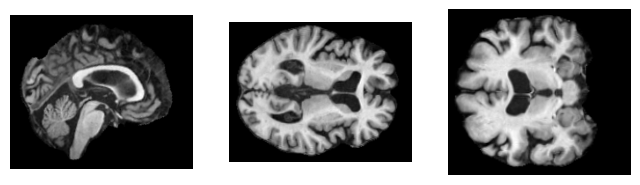

In [ ]:
mri_image = images[0]
# Show a single slice (assuming 3D MRI data)
fig, axes = plt.subplots(1, 3, figsize=(8, 10))
axes[0].imshow(mri_image[mri_image.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_image[:, mri_image.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_image[:, :, mri_image.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

In [1]:
mri_image.cpu().numpy(),.shape

NameError: name 'mri_image' is not defined